# CFTP & Bounding Chain algorithm for a disordered spin system

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import networkx as nx
from scipy.special import gammaln

# configuration of matplotlib for better visualization and paper-quality figures
plt.rcParams.update({
    'figure.figsize': (8, 6),
    'font.size': 22,
    'lines.linewidth': 4,
    'axes.grid': True,
    'legend.fontsize': 12,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.markersize': 10,
    'font.family': 'serif',
    'font.serif': ['Latin Modern Roman'],
    'mathtext.fontset': 'cm',
    'axes.spines.top': False,
    'axes.spines.right': False,
    # remove the box around the legend
    'legend.frameon': False
})

## Setting

Let $G=(V, E)$ a graph. For each $(u, v) \in E$ we define the random variable called _coupling_ $J_{uv}$. For each $v\in V$ define $x(v)\in\{-1, +1\}$. We call $x(v)$ a spin. The _energy_ of a configuration is given by $U(x) = - \sum_{(u,v)\in E} J_{uv}x(u)x(v)$. We define the Gibbs-Boltzmann measure at inverse temperature $\beta$ :

$$\pi_\beta(x) = \frac1{Z_\beta} e^{-\beta U(x)}  \, , \, Z_\beta = \sum_x e^{-\beta U(x)}$$


The Gibbs-Boltzmann measure is also called the equilibrium measure. We want to be able to sample configurations from it. To do so, we aim at using the Coupling From The Past algorithm proposed by Propp and Wilson [insert ref].

Let $(X_n)$ be a Markov Chain of state space $S = \{-1, +1\}^{|V|} = C^{|V|}$. Let the functionnal representation of the Markov Chain be 

$$ 
X_{n+1}(v) = \phi(X_n(v), v_n, r_n, s_n) = \left\lbrace \begin{matrix} X_n(v) \text{ if } v\neq v_n \\ X_n(v) \text{ if } X_n(v)=s_n \\ -X_n(v) \text{ if } X_n(v)=-s_n \text{ and } r< F_\beta(2x(v)h(x, v)) \\ X_n(v) \text{ if } X_n(v)=-s_n \text{ and } r\geq F_\beta(2x(v)h(x,v)) \end{matrix}\right.
$$

where $v_n\sim \text{Unif}(V)$, $s_n\sim\text{Unif}(\{-1, +1\})$, $r_n\sim\text{Unif}([0, 1])$ and 

$$
F_\beta(2x(v)h(x,v)) = \left\lbrace \begin{matrix}  \frac1{1+e^{\beta 2x(v)h(x,v)}} \text{, Glauber Heat Bath} \\ \min(1, e^{-\beta 2x(v)h(x,v)})\text{, Metropolis-Hastings} \end{matrix}\right.
$$

In what preceed, $h(x,v)=\sum_{u\in N(v)} J_{uv}x(u)$ and $N(v)=\{u\in V\,|\, (u,v)\in E\}$.

We define the bounding chain $(Y_n)$ with state space $S' = \{-1, +1, \star\}^{|V|}=C'^{|V|}$ with $\star = \{-1, +1\}$. The update of $(Y_n)$ is done by applying the following algorithm :


1. Start with $Y_0 = \star$
2. For $n\leq$ max_iter:
    1. Draw $v_n$, $r_n$, $s_n$
    2. If $Y_n(v_n) = s_n$
        1. $Y_{n+1}(v_n) = Y_n(v_n)$
    3. If $Y_n(v_n) = -s_n$
        1. Compute $\hbar(Y_n, v_n) = \sum_{u\in N(v_n)} J_{u v_n}\bold 1_{\{ Y_n(u)\neq\star \}} $ and $m(Y_n, v_n) = \sum_{u\in N(v_n)}|J_{u v_n}|\bold 1_{\{Y_n(u) = \star\}}$
        2. Compute $h^+ = \hbar(Y_n, v_n) + m(Y_n, v_n)$ and $h^- = \hbar(Y_n, v_n) - m(Y_n, v_n)$
        3. If $r_n < F_\beta(-2s_nh^{s_n})$
            1. $Y_{n+1}(v_n) = s_n$
        4. Else If $F_\beta(-2s_nh^{s_n})<r_n<F_\beta(-2s_nh^{-s_n})$
            1. $Y_{n+1}(v_n) = \star$
        5. Else If $r_n > F_\beta(-2s_nh^{-s_n})$
            1. $Y_{n+1}(v_n) = Y_n(v_n) = -s_n$.
    4. If $Y_n(v_n)=\star$
        1. Compute $\hbar(Y_n, v_n) = \sum_{u\in N(v_n)} J_{u v_n}\bold 1_{\{ Y_n(u)\neq\star \}} $ and $m(Y_n, v_n) = \sum_{u\in N(v_n)}|J_{u v_n}|\bold 1_{\{Y_n(u) = \star\}}$
        2. Compute $h^+ = \hbar(Y_n, v_n) + m(Y_n, v_n)$ and $h^- = \hbar(Y_n, v_n) - m(Y_n, v_n)$
        3. If $r_n < F_\beta(-2s_nh^{s_n})$
            1. $Y_{n+1}(v_n) = s_n$
        4. Else If $F_\beta(-2s_nh^{s_n})<r_n<F_\beta(-2s_nh^{-s_n})$
            1. $Y_{n+1}(v_n) = Y_n(v_n) = \star$
        5. Else If $r_n > F_\beta(-2s_nh^{-s_n})$
            1. $Y_{n+1}(v_n) = Y_n(v_n) = \star$.

The Bounding Chain is then used as the Markov Chain for the CFTP. To do so we start from a long time in the past $-T$ and simulate the chain forward using the previous algorithm. We check at $T=0$ that $|Y_0(v_n)| = 1$ for all $v\in V$. If this is not the case, we start from further back in the past. At each timestep $t\in[-T, 0]$ the same random numbers $r_t\, s_t$ and random node $v_t$ are used so that the same chain is simulated at each iteration of the CFTP algorithm.

In [5]:
def F_beta_Glauber(beta, U):
    return 1 / (1 + np.exp(2 * beta * U))

def F_beta_Metropolis(beta, U):
    if U <= 0:
        return 1
    else:
        return np.exp(-2 * beta * U)

def CFTP_BC_disordered_naive(beta, G, coupling):
    t = -1
    random_node = []
    random_spin_value = []
    random_real = []
    star = [-1, +1]
    N = G.number_of_nodes()
    while t > -2**15:
        Y = [[-1, +1] for _ in range(N)]  # Initialize the bounding chains to cover all configurations
        for timestep in range(t, 1):
            while len(random_real) < -t:
                random_real.append(np.random.rand())  # Generate random numbers for updates
                random_node.append(np.random.randint(N))
                random_spin_value.append(np.random.choice([-1, 1]))
            actual_random_node = random_node[-timestep-1]
            actual_random_spin_value = random_spin_value[-timestep-1]
            actual_random_real = random_real[-timestep-1]
            # print("Timestep:", timestep, "Random Node:", actual_random_node, "Random Spin Value:", actual_random_spin_value, "Random Real:", actual_random_real)
            
            # case (0)
            if Y[actual_random_node] == [actual_random_spin_value]:
                continue
            
            # case (i)
            elif Y[actual_random_node] == [-actual_random_spin_value]:
                h_bar = 0
                m = 0
                for neighbor in G.neighbors(actual_random_node):
                    if Y[neighbor] != star:
                        h_bar += coupling[actual_random_node, neighbor]*Y[neighbor][0]
                    else:
                        m += np.abs(coupling[actual_random_node, neighbor])
                h_plus = h_bar + actual_random_spin_value*m
                h_minus = h_bar - actual_random_spin_value*m

                if actual_random_real < F_beta_Glauber(beta, -2*actual_random_spin_value*h_plus):
                    Y[actual_random_node] = [actual_random_spin_value]
                elif actual_random_real > F_beta_Glauber(beta, -2*actual_random_spin_value*h_plus) and actual_random_real < F_beta_Glauber(beta, -2*actual_random_spin_value*h_minus):
                    Y[actual_random_node] = star
                elif actual_random_real > F_beta_Glauber(beta, -2*actual_random_spin_value*h_minus):
                    Y[actual_random_node] = [-actual_random_spin_value]
            
            # case (ii)
            elif Y[actual_random_node] == star:
                h_bar = 0
                m = 0
                for neighbor in G.neighbors(actual_random_node):
                    if Y[neighbor] != star:
                        h_bar += coupling[actual_random_node, neighbor]*Y[neighbor][0]
                    else:
                        m += np.abs(coupling[actual_random_node, neighbor])
                h_plus = h_bar + actual_random_spin_value*m
                if actual_random_real < F_beta_Glauber(beta, -2*actual_random_spin_value*h_plus):
                    Y[actual_random_node] = [actual_random_spin_value]
                else:
                    Y[actual_random_node] = star
        
        # Check for coalescence
        if all(len(Y[v])==1 for v in range(N)):
            return np.array([Y[v][0] for v in range(N)]), t  # Return the coalesced configuration
        else:
            t *= 2  # Double the time window for the next iteration
    print("Warning: CFTP did not coalesce after a large number of iterations.")
    return None, np.nan

In [3]:
def CFTP_BC_disordered_optimized(beta, G, coupling):
    t = -1
    random_node = []
    random_spin_value = []
    random_real = []
    star = [-1, +1]
    N = G.number_of_nodes()
    while t > -2**20:
        Y = [[-1, +1] for _ in range(N)]  # Initialize the bounding chains to cover all configurations
        for timestep in range(t, 1):
            while len(random_real) < -t:
                random_real.append(np.random.rand())  # Generate random numbers for updates
                random_node.append(np.random.randint(N))
                random_spin_value.append(np.random.choice([-1, 1]))
            actual_random_node = random_node[-timestep-1]
            actual_random_spin_value = random_spin_value[-timestep-1]
            actual_random_real = random_real[-timestep-1]

            if Y[actual_random_node] != [actual_random_spin_value]:
                h_bar = 0
                m = 0
                for neighbor in G.neighbors(actual_random_node):
                    if Y[neighbor] != star:
                        h_bar += coupling[actual_random_node, neighbor]*Y[neighbor][0]
                    else:
                        m += np.abs(coupling[actual_random_node, neighbor])
                h_minus = h_bar + actual_random_spin_value*m # The "minus" case corresponds to the +s_n value because the sampler are decreasing functions of the local field
                h_plus = h_bar - actual_random_spin_value*m
                if actual_random_real < F_beta_Glauber(beta, -2*actual_random_spin_value*h_plus):
                    Y[actual_random_node] = [actual_random_spin_value]
                elif actual_random_real > F_beta_Glauber(beta, -2*actual_random_spin_value*h_minus) and Y[actual_random_node] == [-actual_random_spin_value]:
                    continue
                else:
                    Y[actual_random_node] = star
                
        # Check for coalescence
        if all(len(Y[v])==1 for v in range(N)):
            return np.array([Y[v][0] for v in range(N)]), t  # Return the coalesced configuration
        else:
            t *= 2  # Double the time window for the next iteration
    print("Warning: CFTP did not coalesce after a large number of iterations.")
    return np.array([np.nan for _ in range(N)]), np.nan

## Test on the Curie-Weiss model

We use a fully connected graph with all couplings equal to 1/2N

In [14]:
def partition_function(beta, N):
    val_m = np.arange(-N, N+1, 2) / N  
    km = N / 2 * (1 + val_m)           
    
    log_prefac = gammaln(N + 1) - gammaln(km + 1) - gammaln(N - km + 1)
    energy = -N * val_m**2 / 2 
    exponents = log_prefac - beta * energy
    
    # We still use the shift to prevent intermediate overflow, 
    # though note that for very large N, Z itself may still exceed float64 limits (~10^308).
    max_exp = np.max(exponents)
    Z = np.exp(max_exp) * np.sum(np.exp(exponents - max_exp))
    return Z

def theoretical_magnetization(beta, N):
    val_m = np.arange(-N, N+1, 2) / N
    km = N / 2 * (1 + val_m)
    
    log_prefac = gammaln(N + 1) - gammaln(km + 1) - gammaln(N - km + 1)
    energy = -N * val_m**2 / 2 
    exponents = log_prefac - beta * energy
    
    # The Log-Sum-Exp trick: subtract max exponent to prevent overflow
    max_exp = np.max(exponents)
    terms = np.exp(exponents - max_exp)
    
    # The exp(max_exp) mathematically cancels out between the numerator and denominator
    mag_sum = np.sum(np.abs(val_m) * terms)
    Z_shifted = np.sum(terms) 
    
    return mag_sum / Z_shifted

def theoretical_magnetization_variance(beta, N):
    val_m = np.arange(-N, N+1, 2) / N
    km = N / 2 * (1 + val_m)
    
    log_prefac = gammaln(N + 1) - gammaln(km + 1) - gammaln(N - km + 1)
    energy = -N * val_m**2 / 2 
    exponents = log_prefac - beta * energy
    
    # The Log-Sum-Exp trick
    max_exp = np.max(exponents)
    terms = np.exp(exponents - max_exp)
    
    Z_shifted = np.sum(terms)
    mean_mag = np.sum(np.abs(val_m) * terms) / Z_shifted
    mean_mag_squared = np.sum((np.abs(val_m)**2) * terms) / Z_shifted
    
    return mean_mag_squared - mean_mag**2

In [15]:
G = nx.complete_graph(100)
couplings = 1/2 * (np.ones((G.number_of_nodes(), G.number_of_nodes())) - np.eye(G.number_of_nodes())) / G.number_of_nodes()

# Compute the magnetization of the resulting configuration for different values of beta
betas = np.linspace(0, 1.1, 100)
magnetizations = []
theoretical_magnetizations = [theoretical_magnetization(b, G.number_of_nodes()) for b in betas]
theoretical_magnetization_variances = [theoretical_magnetization_variance(b, G.number_of_nodes()) for b in betas]
for beta in tqdm(betas):
    temp = []
    for _ in range(10):  # Average over multiple runs to reduce noise
        config, time = CFTP_BC_disordered_optimized(beta=beta, G=G, coupling=couplings)
        magnetization = np.abs(np.mean(config))
        temp.append(magnetization)
    magnetizations.append(np.mean(temp))

 93%|█████████▎| 93/100 [04:02<00:47,  6.81s/it]

 96%|█████████▌| 96/100 [04:31<00:34,  8.73s/it]

 97%|█████████▋| 97/100 [04:40<00:26,  8.91s/it]

 98%|█████████▊| 98/100 [04:52<00:19,  9.75s/it]

100%|██████████| 100/100 [05:14<00:00,  3.15s/it]


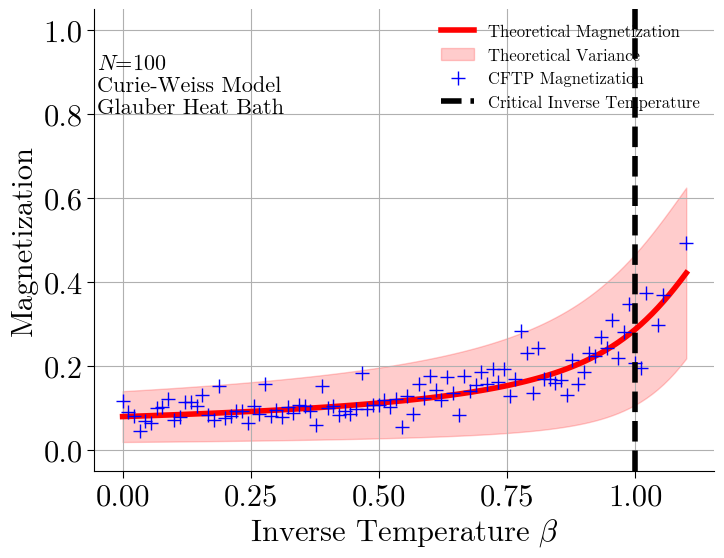

In [16]:
plt.plot(betas, theoretical_magnetizations, '-r', label='Theoretical Magnetization')
plt.fill_between(betas, np.array(theoretical_magnetizations) - np.sqrt(theoretical_magnetization_variances),
                 np.array(theoretical_magnetizations) + np.sqrt(theoretical_magnetization_variances), color='red', alpha=0.2, label='Theoretical Variance')
plt.plot(betas, magnetizations, '+b', label='CFTP Magnetization')
plt.vlines(1.0, -0.05, 1.05, color='k', linestyle='--', label=r'Critical Inverse Temperature')
plt.text(-0.05, 0.8, f"$N$=100\nCurie-Weiss Model\nGlauber Heat Bath", fontsize=16)
plt.ylim(-0.05, 1.05)
plt.xlabel(r'Inverse Temperature $\beta$')
plt.ylabel('Magnetization')
plt.legend()
plt.show()

## Test on ferromagnetic Erdös-Rényi graph

In [ ]:
N = 100
# betas = np.linspace(0, 1.0, 100)
magnetizations_fixed_d = []
d_values = [2, 4, 6, 10]
lst_beta = []
for d in d_values:
    G = nx.erdos_renyi_graph(N, d/N)
    lambda_bar = d/N * (N-2)
    beta_critical = np.arctanh(1/lambda_bar)
    betas = np.linspace(0, beta_critical*1.1, 100)
    lst_beta.append(betas)
    couplings = np.ones((G.number_of_nodes(), G.number_of_nodes())) - np.eye(G.number_of_nodes())
    magnetizations = []
    for beta in tqdm(betas):
        temp = []
        for _ in range(10):
            config, time = CFTP_BC_disordered_optimized(beta=beta, G=G, coupling=couplings)
            magnetization = np.abs(np.mean(config))
            temp.append(magnetization)
        magnetizations.append(np.mean(temp))
    magnetizations_fixed_d.append(magnetizations)

 34%|███▍      | 34/100 [00:20<01:22,  1.25s/it]

 36%|███▌      | 36/100 [00:23<01:35,  1.49s/it]

 37%|███▋      | 37/100 [00:25<01:48,  1.72s/it]

 38%|███▊      | 38/100 [00:27<01:49,  1.76s/it]

 39%|███▉      | 39/100 [00:29<01:50,  1.81s/it]

...

 96%|█████████▌| 96/100 [04:50<00:23,  5.97s/it]

 97%|█████████▋| 97/100 [04:56<00:18,  6.01s/it]

 98%|█████████▊| 98/100 [05:02<00:11,  5.94s/it]

 99%|█████████▉| 99/100 [05:07<00:05,  5.85s/it]

100%|██████████| 100/100 [05:13<00:00,  3.13s/it]

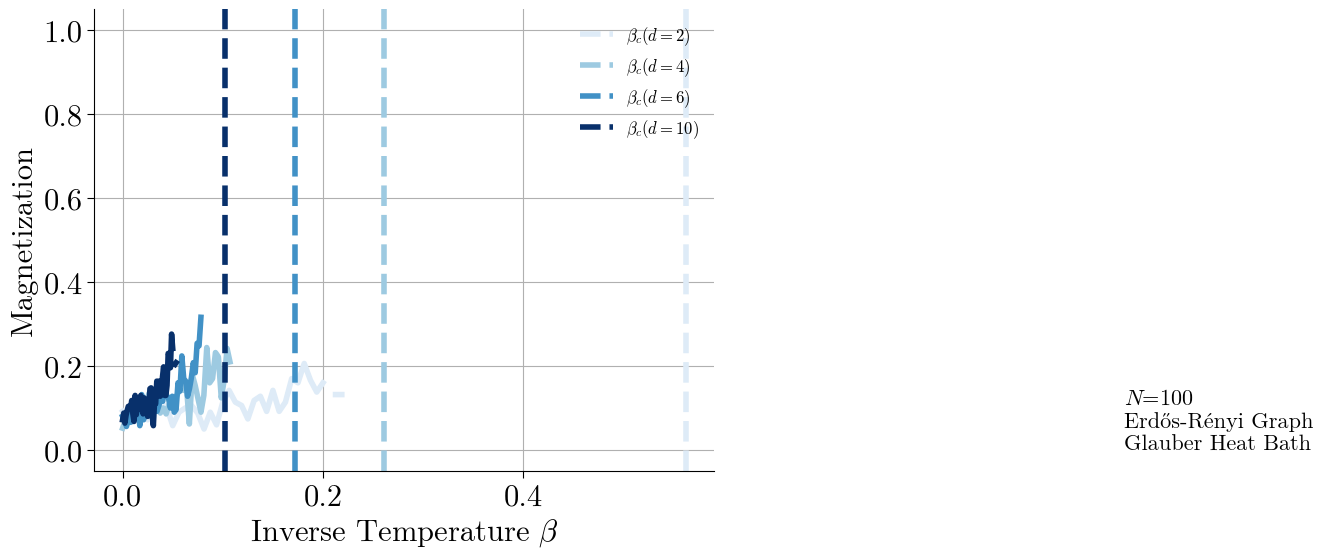

In [21]:
for d, magnetizations in zip(d_values, magnetizations_fixed_d):
    betas = np.linspace(0, np.arctanh(1/(d/N * (N-2)))*1.1, 100)
    color = plt.cm.Blues((d-1)/8)  # Normalize d to range [0, 1] for colormap
    plt.plot(betas, magnetizations, color=color)
    plt.vlines(np.arctanh(1/(d/N * (N-2))), -0.05, 1.05, color=color, linestyle='--', label=rf'$\beta_c(d={d})$')
plt.text(1.0, 0, "$N$=100\nErdős-Rényi Graph\nGlauber Heat Bath", fontsize=16)
plt.ylim(-0.05, 1.05)
plt.xlabel(r'Inverse Temperature $\beta$')
plt.ylabel('Magnetization')
plt.legend()
plt.show()

## Test on Random Couplings Erdös-Rényi graphs

Critical Beta: 0.3310214345644773


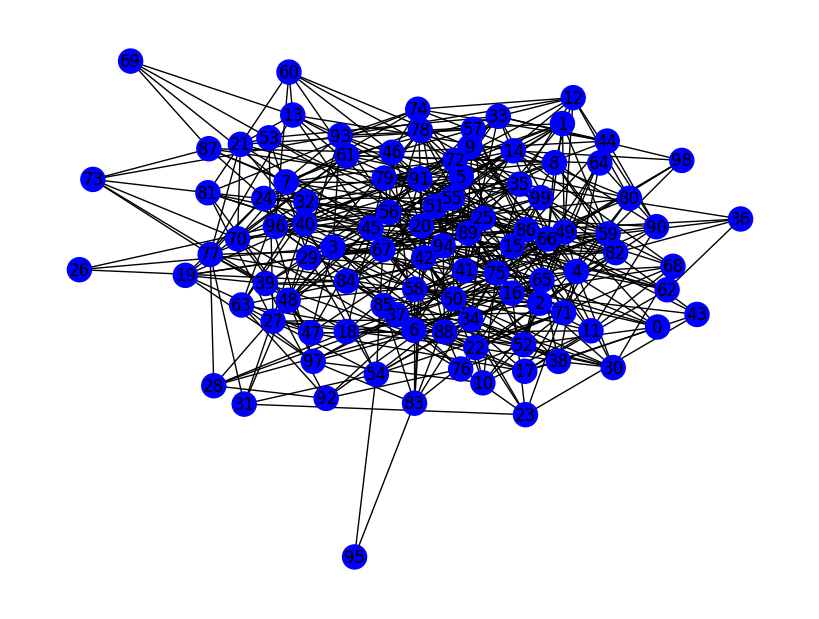

In [42]:
N = 100
d = 10
G = nx.erdos_renyi_graph(N, d/N)
beta_critical = np.arctanh(np.sqrt(1/(d/N * (N-2))))
print("Critical Beta:", beta_critical)
couplings = np.random.choice([-1, 1], size=(N, N)) * (np.ones((N, N)) - np.eye(N))
beta = 0.1
config, time = CFTP_BC_disordered_optimized(beta=beta, G=G, coupling=couplings)

# Display the obtained graph
color_map = ['red' if config[v] == 1 else 'blue' for v in G.nodes()]
nx.draw(G, node_color=color_map, with_labels=True)
plt.show()

In [ ]:
N = 100
betas = np.linspace(0, 1.0, 100)
magnetizations_fixed_d = []
d_values = [2, 4, 6, 10]
for d in d_values:
    G = nx.erdos_renyi_graph(N, d/N) 
    couplings = coupling = np.random.choice([-1, 1], size=(G.number_of_nodes(), G.number_of_nodes())) * (np.ones((G.number_of_nodes(), G.number_of_nodes())) - np.eye(G.number_of_nodes()))
    magnetizations = []
    for beta in betas:
        temp = []
        for _ in range(10):
            config, time = CFTP_BC_disordered_optimized(beta=beta, G=G, coupling=couplings)
            magnetization = np.abs(np.mean(config))
            temp.append(magnetization)
        magnetizations.append(np.mean(temp))
    magnetizations_fixed_d.append(magnetizations)

In [ ]:
for d, magnetizations in zip(d_values, magnetizations_fixed_d):
    color = plt.cm.Blues((d-1)/8)  # Normalize d to range [0, 1] for colormap
    plt.plot(betas, magnetizations, color=color, label=rf'$d={d}$')
plt.text(0, 0.8, "$N$=100\nErdős-Rényi Graph\nGlauber Heat Bath\n$J_{ij}\sim\\text{Unif}(\{-1, +1\})$", fontsize=16)
plt.ylim(-0.05, 1.05)
plt.xlabel(r'Inverse Temperature $\beta$')
plt.ylabel('Magnetization')
plt.legend()
plt.show()

## Test of free energy estimation from sampled configuration of spin glass on random graph

From the book "Information, Physics and Computation" from Mézard and Montanari we have (theorem 17.3) that the free energy of a spin glass on a random graph of degree distribution $\Lambda$ with finite second moment and average $\bar\Lambda$

$$ \lim_{N\to\infty} \frac1N Z_N(\beta) = \log2 + \frac12\bar\Lambda\log\cosh\beta $$

for all $\beta$ that verifies $\bar\lambda (\tanh\beta)^2<1$ where $\bar\lambda$ is equal to $\bar\Lambda$ for an ER graph.

In [7]:
N = 100
d = 10
G = nx.erdos_renyi_graph(N, d/N)
couplings = np.random.choice([-1, 1], size=(G.number_of_nodes(), G.number_of_nodes())) * (np.ones((G.number_of_nodes(), G.number_of_nodes())) - np.eye(G.number_of_nodes()))
# avg_degree = np.mean([degree for node, degree in G.degree()])
nb_edges = G.number_of_edges()
lambda_bar = d/N * (N-2)
beta_critical = np.arctanh(np.sqrt(1/lambda_bar))
betas = np.linspace(0, beta_critical*1.2, 10)
theoretical_energy_per_spin = np.array([-nb_edges/N * np.tanh(b) for b in betas])

mcmc_energy_per_spin = []

for b in tqdm(betas):
    temp = []
    for _ in range(2):
        config, time = CFTP_BC_disordered_optimized(beta=b, G=G, coupling=couplings)
        energy = 0
        for i, j in G.edges():
            energy -= couplings[i, j] * config[i] * config[j]
        energy_per_spin = energy / N
        temp.append(energy_per_spin)
    mcmc_energy_per_spin.append(np.mean(temp))

  0%|          | 0/10 [00:00<?, ?it/s]

 20%|██        | 2/10 [00:00<00:01,  6.36it/s]

 30%|███       | 3/10 [00:32<01:35, 13.58s/it]

 40%|████      | 4/10 [01:06<02:07, 21.31s/it]

 50%|█████     | 5/10 [01:42<02:11, 26.21s/it]

 60%|██████    | 6/10 [02:18<01:58, 29.52s/it]

 70%|███████   | 7/10 [02:55<01:35, 31.87s/it]

 80%|████████  | 8/10 [03:30<01:06, 33.02s/it]

 90%|█████████ | 9/10 [04:08<00:34, 34.33s/it]

100%|██████████| 10/10 [04:45<00:00, 28.57s/it]

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_98032/3726347046.py:6: SyntaxWarning: invalid escape sequence '\s'
  plt.text(beta_critical*1.15, -3, '$N$=100\nErdős-Rényi Graph\nGlauber Heat Bath\n$J_{ij}\sim\\text{Unif}(\{\pm1\})$', fontsize=16)


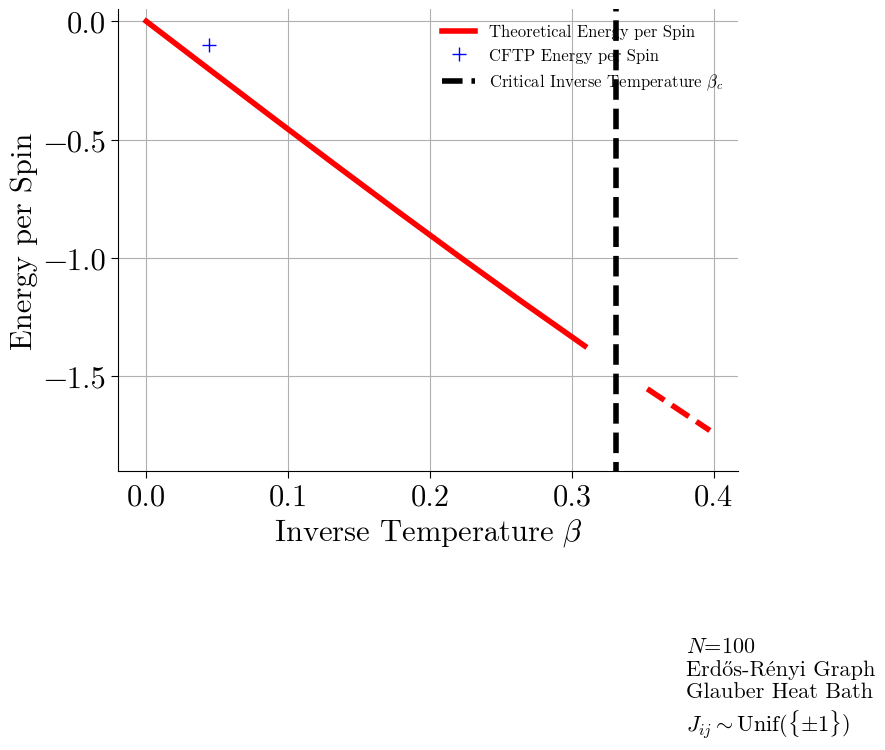

In [8]:
plt.plot(betas[betas < beta_critical], theoretical_energy_per_spin[betas < beta_critical], '-r', label='Theoretical Energy per Spin')
plt.plot(betas[betas >= beta_critical], theoretical_energy_per_spin[betas >= beta_critical], '--r')
plt.plot(betas, mcmc_energy_per_spin, '+b', label='CFTP Energy per Spin')
plt.vlines(beta_critical, np.min(theoretical_energy_per_spin)*1.2, 0.1, color='k', linestyle='--', label=r'Critical Inverse Temperature $\beta_c$')
plt.ylim(np.min(theoretical_energy_per_spin)*1.1, 0.05)
plt.text(beta_critical*1.15, -3, '$N$=100\nErdős-Rényi Graph\nGlauber Heat Bath\n$J_{ij}\sim\\text{Unif}(\{\pm1\})$', fontsize=16)
plt.xlabel(r'Inverse Temperature $\beta$')
plt.ylabel('Energy per Spin')
plt.legend()
plt.show()